# Exploratory Data Analysis (EDA)
**Project:** Impact of Global Crises on Financial Markets

In this notebook we explore how financial markets behaved before and after each crisis.

In [50]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
import os

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries imported.')

Libraries imported.


In [51]:
# Load data saved in data_collection notebook
save_dir = os.path.expanduser('~/Desktop/data')

prices  = pd.read_csv(os.path.join(save_dir, 'prices.csv'),  index_col=0, parse_dates=True)
returns = pd.read_csv(os.path.join(save_dir, 'returns.csv'), index_col=0, parse_dates=True)

print(f'Prices:  {prices.shape[0]} days, {prices.shape[1]} assets')
print(f'Returns: {returns.shape[0]} days, {returns.shape[1]} assets')
print('Data loaded successfully.')

Prices:  6292 days, 10 assets
Returns: 6291 days, 10 assets
Data loaded successfully.


In [52]:
# Crisis dates
CRISES = {
    '9/11 (2001)':             '2001-09-11',
    'Iraq War (2003)':         '2003-03-20',
    'Financial Crisis (2008)': '2008-09-15',
    'COVID-19 (2020)':         '2020-03-11',
    'Russia-Ukraine (2022)':   '2022-02-24',
    'Israel-Hamas (2023)':     '2023-10-07',
}

## 1. S&P 500 Overview
Full timeline with all crisis dates marked.

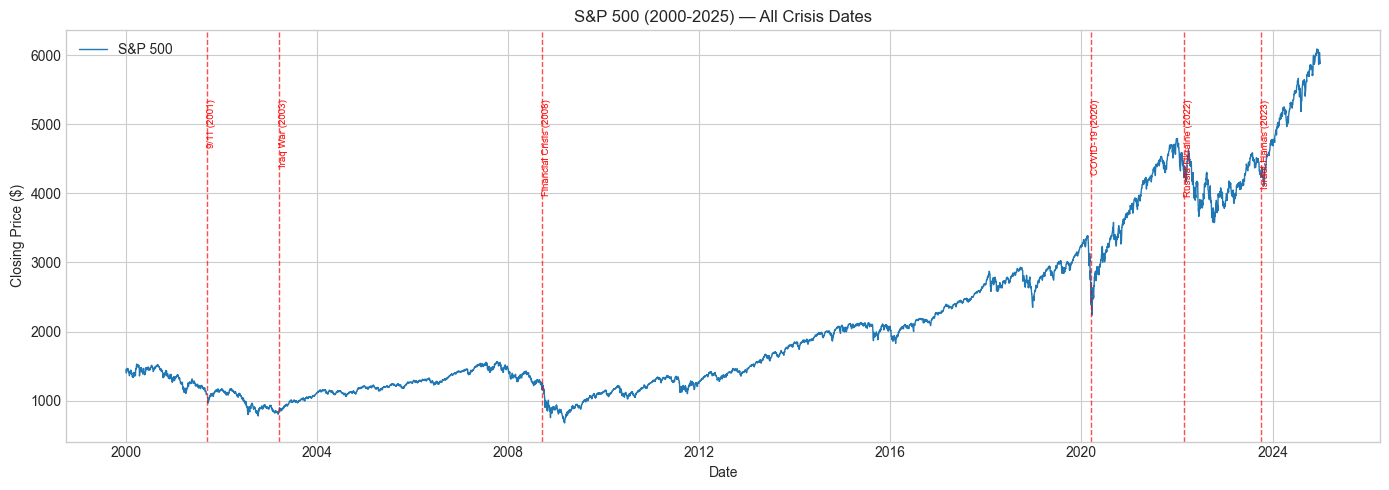

In [53]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prices.index, prices['SP500'], color='#1f77b4', linewidth=1, label='S&P 500')

for crisis_name, crisis_date_str in CRISES.items():
    crisis_date = pd.Timestamp(crisis_date_str)
    ax.axvline(x=crisis_date, color='red', linestyle='--', alpha=0.7, linewidth=1)
    ax.text(crisis_date, prices['SP500'].max() * 0.88, crisis_name,
            rotation=90, fontsize=7, color='red', va='top')

ax.set_title('S&P 500 (2000-2025) — All Crisis Dates')
ax.set_xlabel('Date')
ax.set_ylabel('Closing Price ($)')
ax.legend()
plt.tight_layout()
plt.show()

## 2. Crisis Windows — S&P 500 Price Around Each Crisis
For each crisis: 30 days before and 30 days after.
The vertical red line = crisis date.

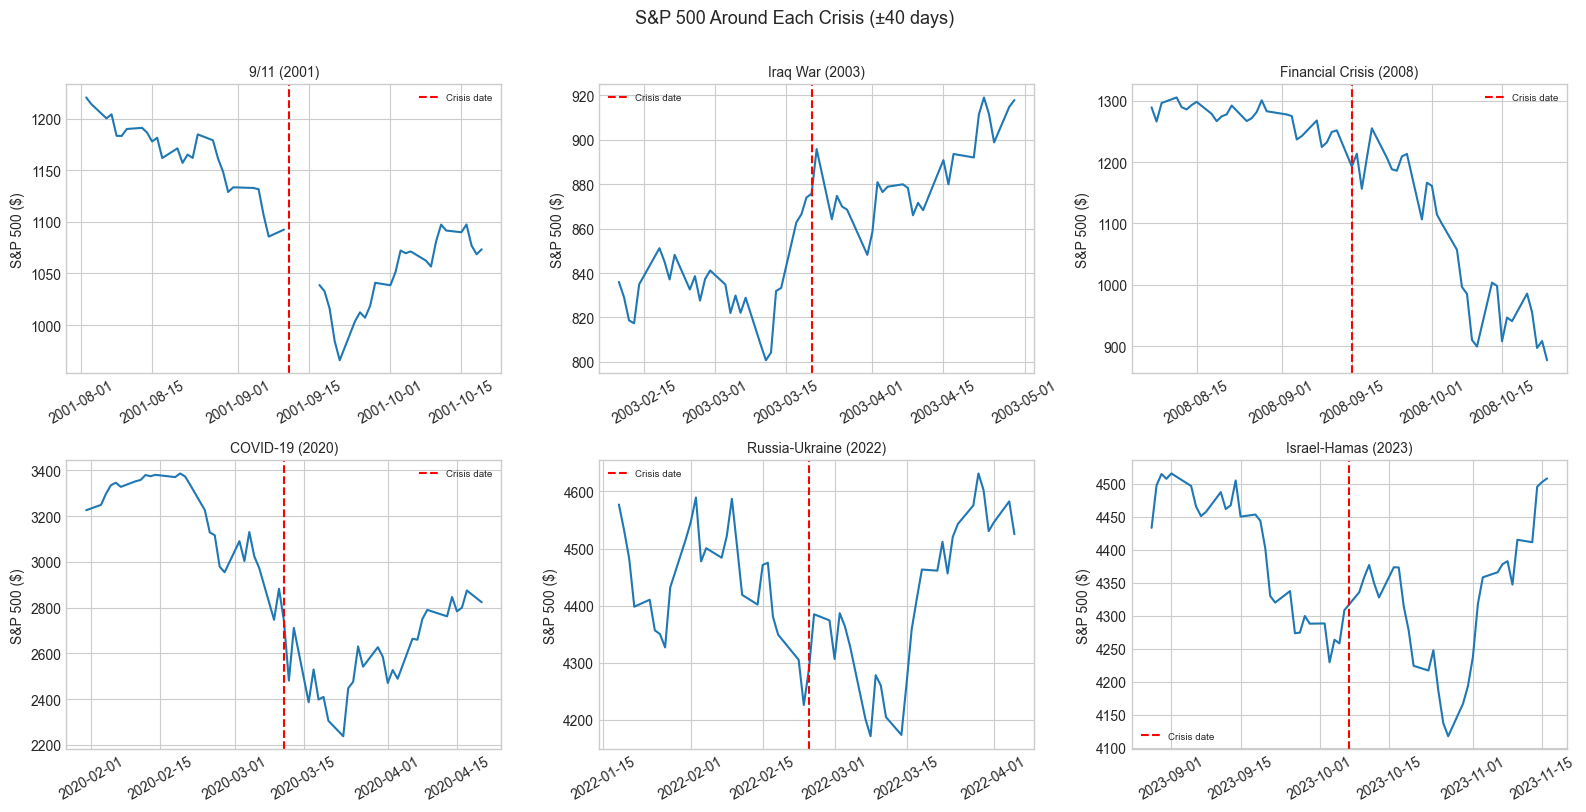

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (crisis_name, crisis_date_str) in enumerate(CRISES.items()):
    crisis_date = pd.Timestamp(crisis_date_str)
    start = crisis_date - pd.Timedelta(days=40)
    end   = crisis_date + pd.Timedelta(days=40)

    window = prices['SP500'].loc[start:end]

    ax = axes[i]
    ax.plot(window.index, window.values, color='#1f77b4', linewidth=1.5)
    ax.axvline(x=crisis_date, color='red', linestyle='--', linewidth=1.5, label='Crisis date')
    ax.set_title(crisis_name, fontsize=10)
    ax.set_ylabel('S&P 500 ($)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7)

plt.suptitle('S&P 500 Around Each Crisis (±40 days)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 3. Average Daily Return — Before vs After Each Crisis
Compares the average daily return in the 30 days before vs 30 days after each crisis.
This is the core of our analysis.

In [55]:
results = []

for crisis_name, crisis_date_str in CRISES.items():
    crisis_date = pd.Timestamp(crisis_date_str)
    pre_start   = crisis_date - pd.Timedelta(days=30)
    post_end    = crisis_date + pd.Timedelta(days=30)

    pre_ret  = returns['SP500'].loc[pre_start  : crisis_date - pd.Timedelta(days=1)]
    post_ret = returns['SP500'].loc[crisis_date : post_end]

    results.append({
        'Crisis':       crisis_name,
        'Pre mean (%)':  round(pre_ret.mean(), 3),
        'Post mean (%)': round(post_ret.mean(), 3),
        'Pre std (%)':   round(pre_ret.std(), 3),
        'Post std (%)':  round(post_ret.std(), 3),
    })

summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

                 Crisis  Pre mean (%)  Post mean (%)  Pre std (%)  Post std (%)
            9/11 (2001)        -0.421          0.042        1.082         2.012
        Iraq War (2003)         0.220          0.115        1.565         1.450
Financial Crisis (2008)        -0.181         -1.275        1.500         4.842
        COVID-19 (2020)        -0.639          0.007        2.985         5.683
  Russia-Ukraine (2022)        -0.194          0.341        1.414         1.502
    Israel-Hamas (2023)        -0.160          0.067        0.785         0.957


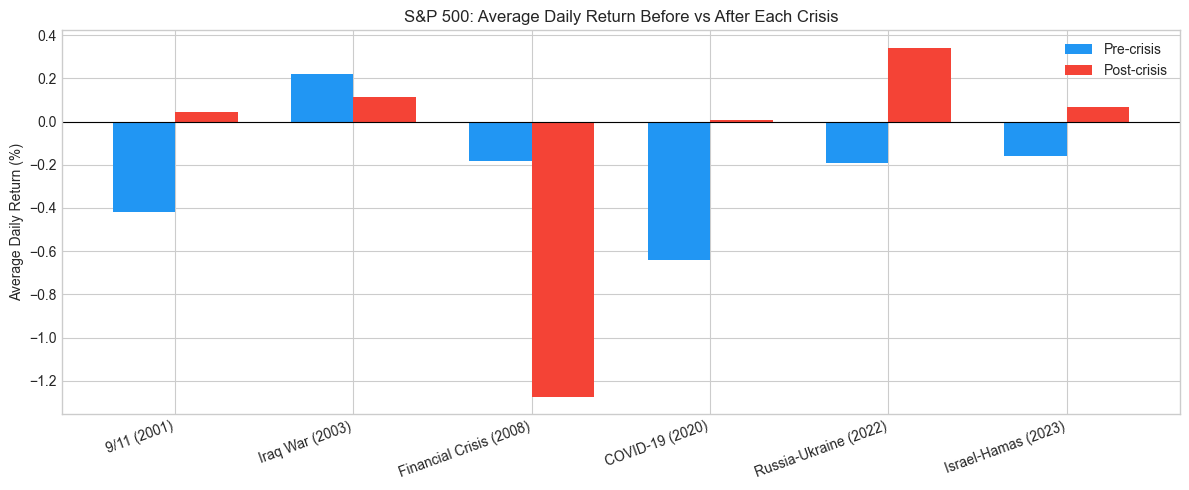

In [56]:
# Bar chart: Pre vs Post mean return for each crisis
x = np.arange(len(summary_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, summary_df['Pre mean (%)'],  width, label='Pre-crisis',  color='#2196F3')
bars2 = ax.bar(x + width/2, summary_df['Post mean (%)'], width, label='Post-crisis', color='#F44336')

ax.set_xticks(x)
ax.set_xticklabels(summary_df['Crisis'], rotation=20, ha='right')
ax.set_ylabel('Average Daily Return (%)')
ax.set_title('S&P 500: Average Daily Return Before vs After Each Crisis')
ax.axhline(0, color='black', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Volatility — Before vs After Each Crisis
Volatility = standard deviation of daily returns.
Higher volatility = more uncertainty in the market.

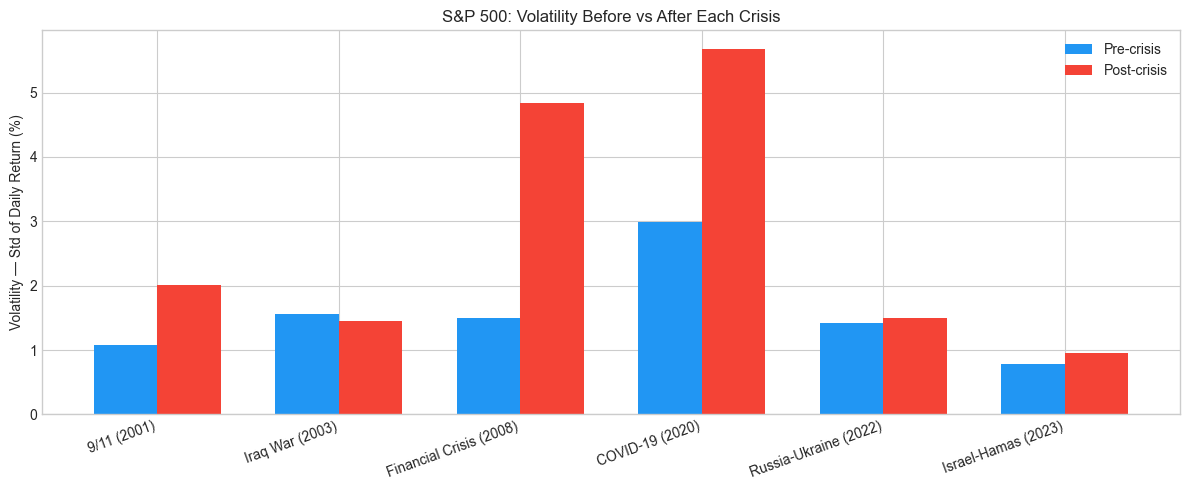

In [57]:
x = np.arange(len(summary_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, summary_df['Pre std (%)'],  width, label='Pre-crisis',  color='#2196F3')
ax.bar(x + width/2, summary_df['Post std (%)'], width, label='Post-crisis', color='#F44336')

ax.set_xticks(x)
ax.set_xticklabels(summary_df['Crisis'], rotation=20, ha='right')
ax.set_ylabel('Volatility — Std of Daily Return (%)')
ax.set_title('S&P 500: Volatility Before vs After Each Crisis')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Sector Comparison — Post-Crisis Returns
Which sectors were hit hardest? Which recovered fastest?
We compare average post-crisis return across all sectors.

In [58]:
sectors = ['Defense', 'Energy', 'Health', 'Tech', 'Aviation']

sector_results = []

for crisis_name, crisis_date_str in CRISES.items():
    crisis_date = pd.Timestamp(crisis_date_str)
    post_end    = crisis_date + pd.Timedelta(days=30)

    row = {'Crisis': crisis_name}
    for sector in sectors:
        if sector in returns.columns:
            post_ret = returns[sector].loc[crisis_date : post_end]
            row[sector] = round(post_ret.mean(), 3)
        else:
            row[sector] = None
    sector_results.append(row)

sector_df = pd.DataFrame(sector_results).set_index('Crisis')
print(sector_df)

                         Defense  Energy  Health   Tech  Aviation
Crisis                                                           
9/11 (2001)                1.026  -0.006  -0.191  0.168    -0.743
Iraq War (2003)           -0.285  -0.017   0.008 -0.018    -0.202
Financial Crisis (2008)   -1.196  -1.751  -1.041 -1.252     0.044
COVID-19 (2020)            0.255   0.188   0.118  0.084    -2.179
Russia-Ukraine (2022)      0.770   0.760   0.359  0.358    -0.158
Israel-Hamas (2023)        0.587   0.009  -0.061  0.136    -0.517


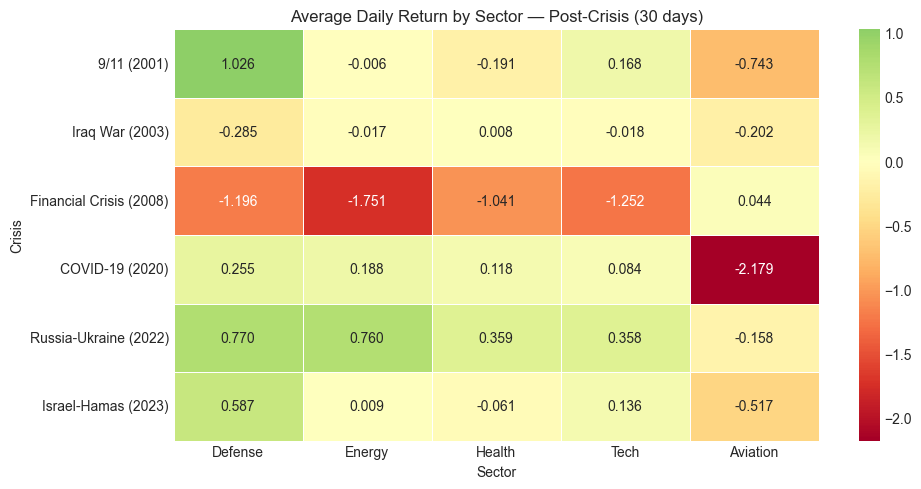

In [59]:
# Heatmap: sector returns per crisis
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    sector_df.astype(float),
    annot=True, fmt='.3f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Average Daily Return by Sector — Post-Crisis (30 days)')
ax.set_xlabel('Sector')
ax.set_ylabel('Crisis')
plt.tight_layout()
plt.show()

## 6. VIX — Fear Index Around Each Crisis
VIX measures market volatility expectations.
Higher VIX = more fear in the market.
We expect VIX to spike during crises.

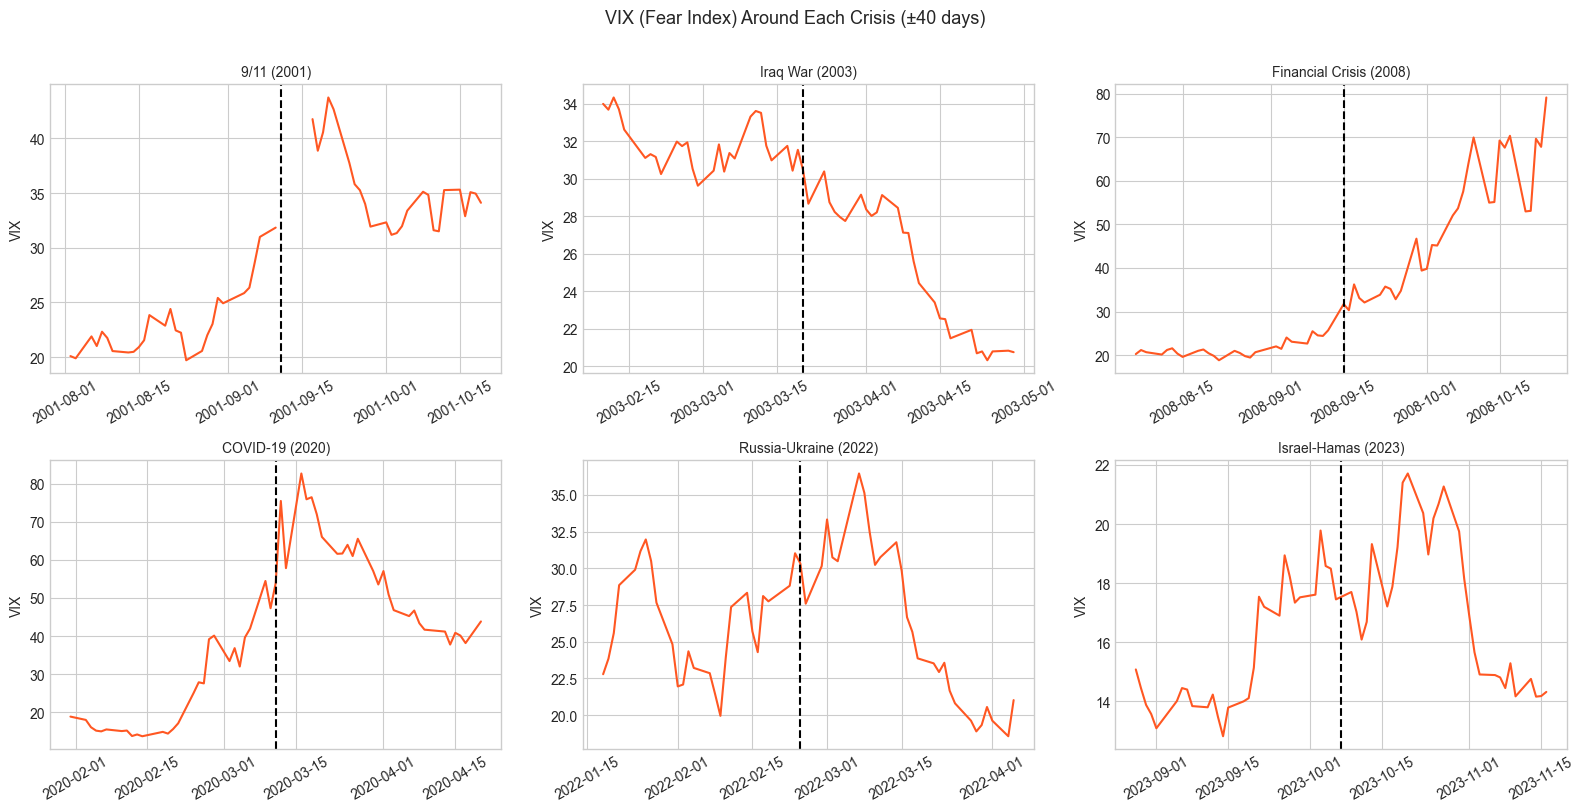

In [60]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (crisis_name, crisis_date_str) in enumerate(CRISES.items()):
    crisis_date = pd.Timestamp(crisis_date_str)
    start = crisis_date - pd.Timedelta(days=40)
    end   = crisis_date + pd.Timedelta(days=40)

    window = prices['VIX'].loc[start:end]

    ax = axes[i]
    ax.plot(window.index, window.values, color='#FF5722', linewidth=1.5)
    ax.axvline(x=crisis_date, color='black', linestyle='--', linewidth=1.5)
    ax.set_title(crisis_name, fontsize=10)
    ax.set_ylabel('VIX')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('VIX (Fear Index) Around Each Crisis (±40 days)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Cumulative Return — Post-Crisis Recovery
Starting from crisis date = 0%, how much did S&P 500 recover in 30 days?

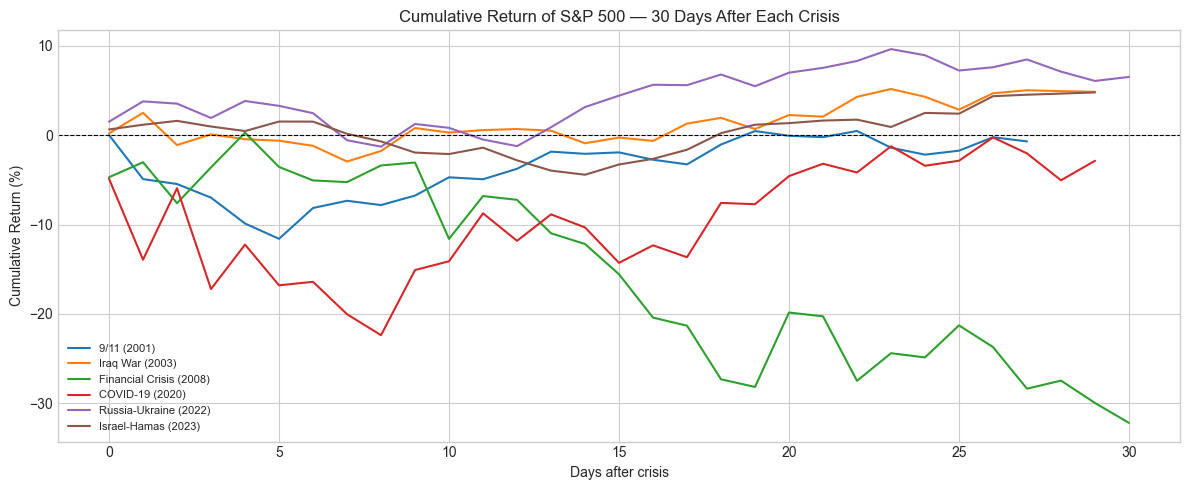

In [61]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b']

for i, (crisis_name, crisis_date_str) in enumerate(CRISES.items()):
    crisis_date = pd.Timestamp(crisis_date_str)
    post_end = crisis_date + pd.offsets.BusinessDay(30)

    post_ret = returns['SP500'].loc[crisis_date : post_end]

    # Cumulative return: (1 + r1/100) * (1 + r2/100) * ... - 1
    cumulative = (1 + post_ret / 100).cumprod() - 1
    cumulative = cumulative * 100  # convert to percent

    days = range(len(cumulative))
    ax.plot(days, cumulative.values, label=crisis_name, color=colors[i], linewidth=1.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cumulative Return of S&P 500 — 30 Days After Each Crisis')
ax.set_xlabel('Days after crisis')
ax.set_ylabel('Cumulative Return (%)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Macroeconomic Indicators — FRED Data
Loading Fed Rate, CPI, Unemployment and M2 from FRED.

In [62]:
# Load macro data
macro = pd.read_csv(os.path.expanduser('~/Desktop/data/macro.csv'), index_col=0, parse_dates=True)
print(f'Macro data loaded: {macro.shape[0]} days, {macro.shape[1]} indicators')
macro.head()

Macro data loaded: 9133 days, 4 indicators


,Fed_Rate,CPI,Unemploy,M2
2000-01-01,5.45,169.3,4.0,4667.6
2000-01-02,5.45,169.3,4.0,4667.6
2000-01-03,5.45,169.3,4.0,4667.6
2000-01-04,5.45,169.3,4.0,4667.6
2000-01-05,5.45,169.3,4.0,4667.6


## 9. Fed Rate & Unemployment Around Each Crisis
How did the Federal Reserve respond? Did unemployment rise after each crisis?

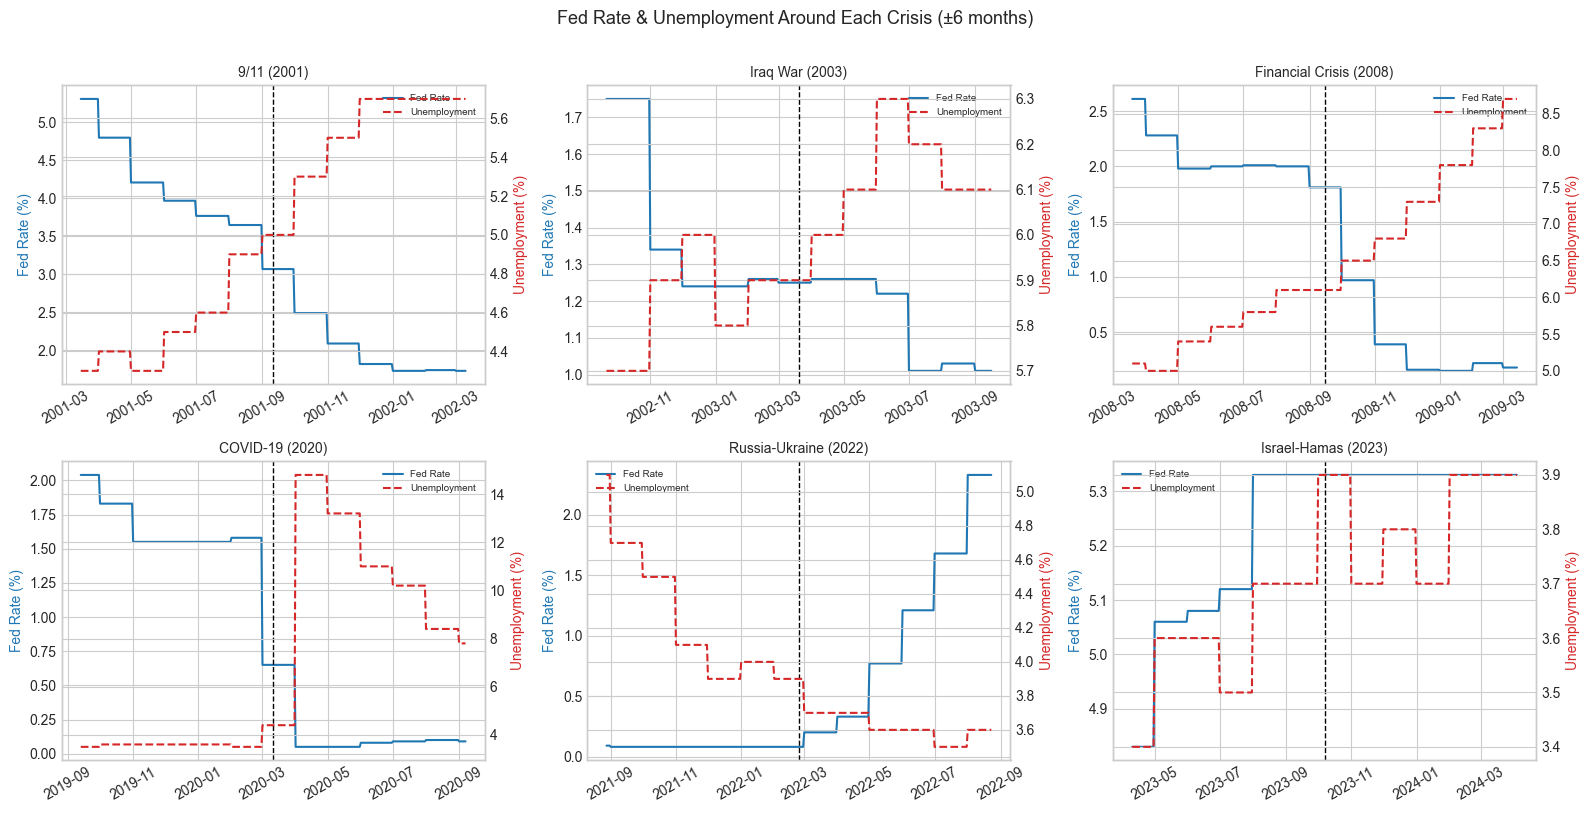

In [63]:
# Fed Rate and Unemployment around each crisis
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (crisis_name, crisis_date_str) in enumerate(CRISES.items()):
    crisis_date = pd.Timestamp(crisis_date_str)
    start = crisis_date - pd.Timedelta(days=180)
    end   = crisis_date + pd.Timedelta(days=180)

    window = macro.loc[start:end]

    ax = axes[i]
    ax2 = ax.twinx()  # second y-axis

    ax.plot(window.index, window['Fed_Rate'], color='#1f77b4', linewidth=1.5, label='Fed Rate')
    ax2.plot(window.index, window['Unemploy'], color='#d62728', linewidth=1.5, linestyle='--', label='Unemployment')
    ax.axvline(x=crisis_date, color='black', linestyle='--', linewidth=1)

    ax.set_title(crisis_name, fontsize=10)
    ax.set_ylabel('Fed Rate (%)', color='#1f77b4')
    ax2.set_ylabel('Unemployment (%)', color='#d62728')
    ax.tick_params(axis='x', rotation=30)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

plt.suptitle('Fed Rate & Unemployment Around Each Crisis (±6 months)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. CPI (Inflation) Around Each Crisis
Did inflation change after each crisis? Post-COVID surge is clearly visible.

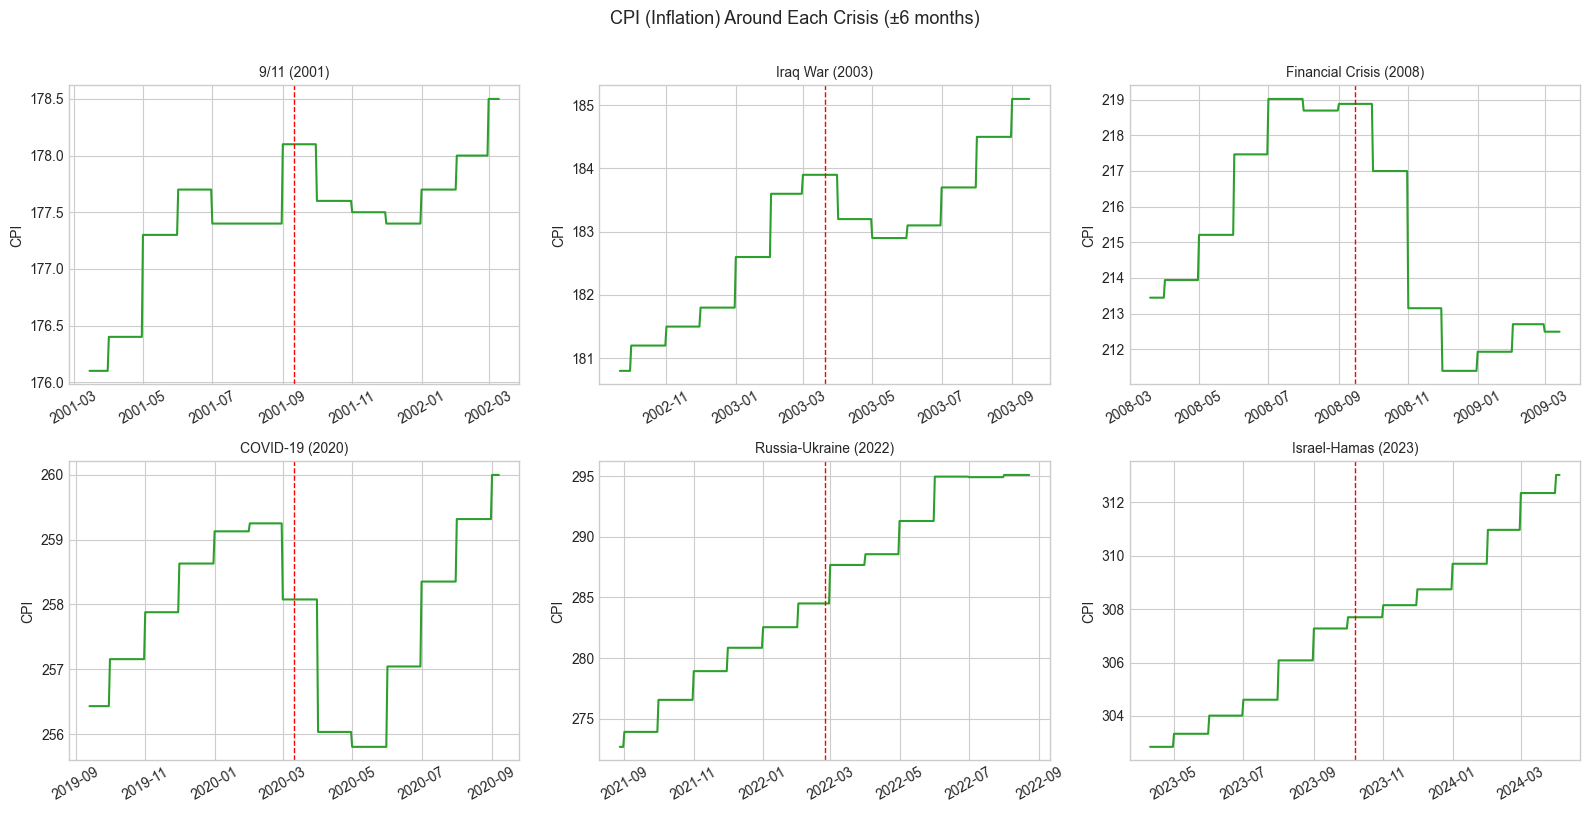

In [64]:
# CPI (inflation) around each crisis
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (crisis_name, crisis_date_str) in enumerate(CRISES.items()):
    crisis_date = pd.Timestamp(crisis_date_str)
    start = crisis_date - pd.Timedelta(days=180)
    end   = crisis_date + pd.Timedelta(days=180)

    window = macro.loc[start:end]

    ax = axes[i]
    ax.plot(window.index, window['CPI'], color='#2ca02c', linewidth=1.5)
    ax.axvline(x=crisis_date, color='red', linestyle='--', linewidth=1)
    ax.set_title(crisis_name, fontsize=10)
    ax.set_ylabel('CPI')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('CPI (Inflation) Around Each Crisis (±6 months)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 11. MSCI World vs S&P 500
How did global markets behave compared to US markets during each crisis?
Note: MSCI World data is available from 2010 onwards.

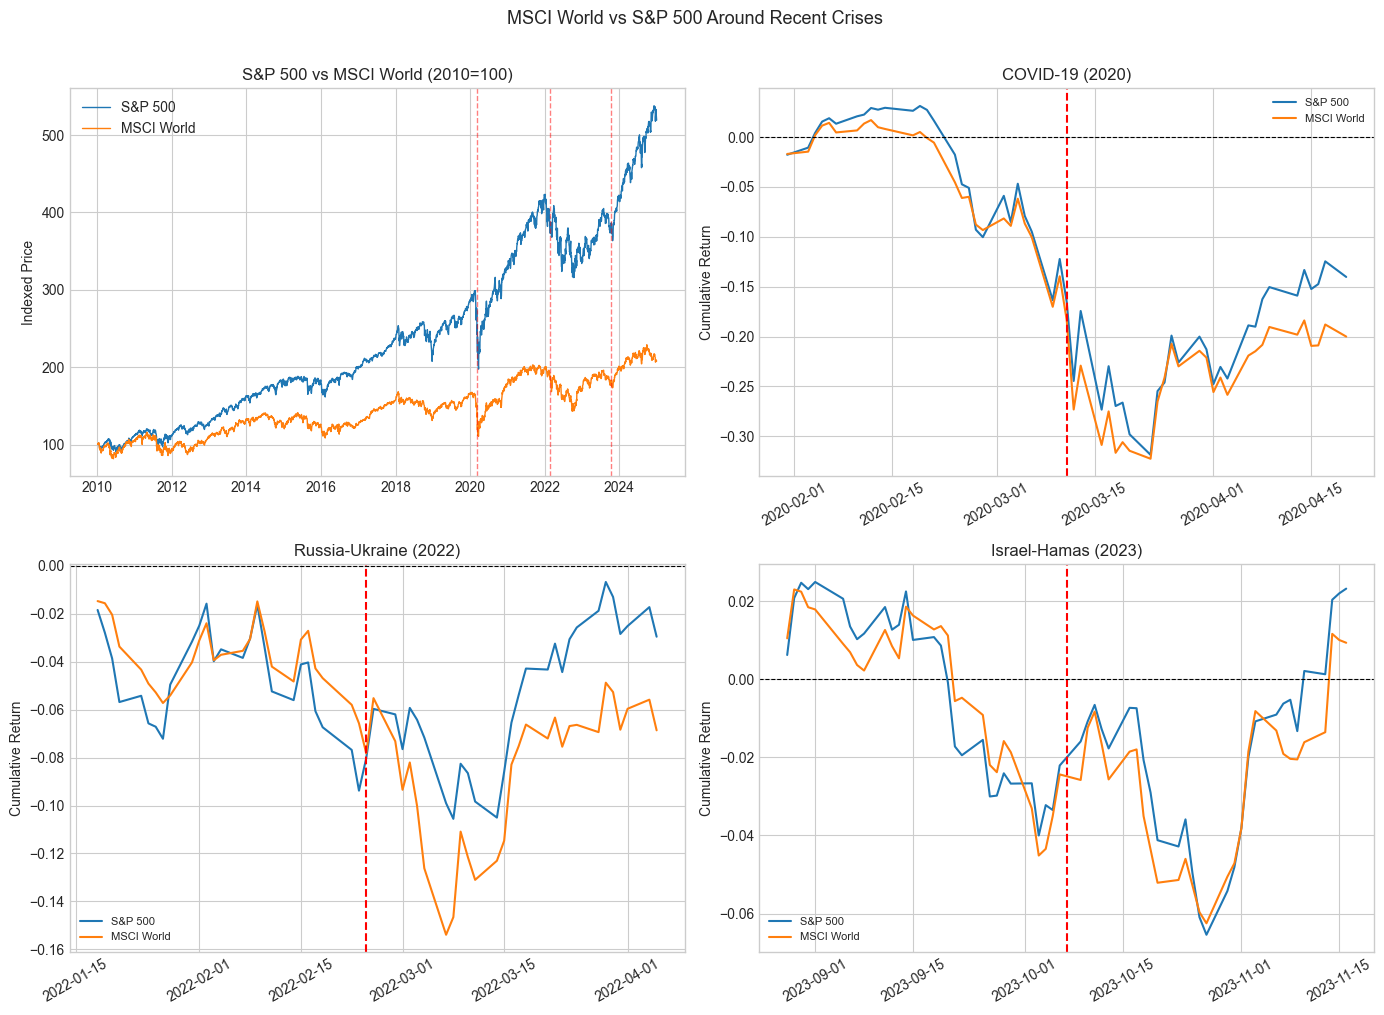

In [65]:
# MSCI World vs SP500 comparison (available from 2010)
if 'MSCI_World' in prices.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    recent_crises = {
        'COVID-19 (2020)':       '2020-03-11',
        'Russia-Ukraine (2022)': '2022-02-24',
        'Israel-Hamas (2023)':   '2023-10-07',
    }

    # Full timeline comparison
    ax = axes[0]
    start = '2010-01-01'
    sp500_norm  = prices['SP500'].loc[start:]  / prices['SP500'].loc[start:].iloc[0] * 100
    msci_norm   = prices['MSCI_World'].loc[start:] / prices['MSCI_World'].loc[start:].iloc[0] * 100
    ax.plot(sp500_norm.index, sp500_norm.values, color='#1f77b4', linewidth=1, label='S&P 500')
    ax.plot(msci_norm.index,  msci_norm.values,  color='#ff7f0e', linewidth=1, label='MSCI World')
    for crisis_name, crisis_date_str in recent_crises.items():
        ax.axvline(x=pd.Timestamp(crisis_date_str), color='red', linestyle='--', alpha=0.5, linewidth=1)
    ax.set_title('S&P 500 vs MSCI World (2010=100)')
    ax.set_ylabel('Indexed Price')
    ax.legend()

    # Crisis windows
    for i, (crisis_name, crisis_date_str) in enumerate(recent_crises.items()):
        crisis_date = pd.Timestamp(crisis_date_str)
        start = crisis_date - pd.Timedelta(days=40)
        end   = crisis_date + pd.Timedelta(days=40)

        sp = returns['SP500'].loc[start:end]
        msci = returns['MSCI_World'].loc[start:end]

        ax = axes[i+1]
        ax.plot(sp.index,   (1 + sp/100).cumprod()   - 1, color='#1f77b4', label='S&P 500')
        ax.plot(msci.index, (1 + msci/100).cumprod() - 1, color='#ff7f0e', label='MSCI World')
        ax.axvline(x=crisis_date, color='red', linestyle='--', linewidth=1.5)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_title(crisis_name)
        ax.set_ylabel('Cumulative Return')
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30)

    plt.suptitle('MSCI World vs S&P 500 Around Recent Crises', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

## 12. Correlation Matrix of Asset Returns
How do different assets move together — and which ones diverge during crises?

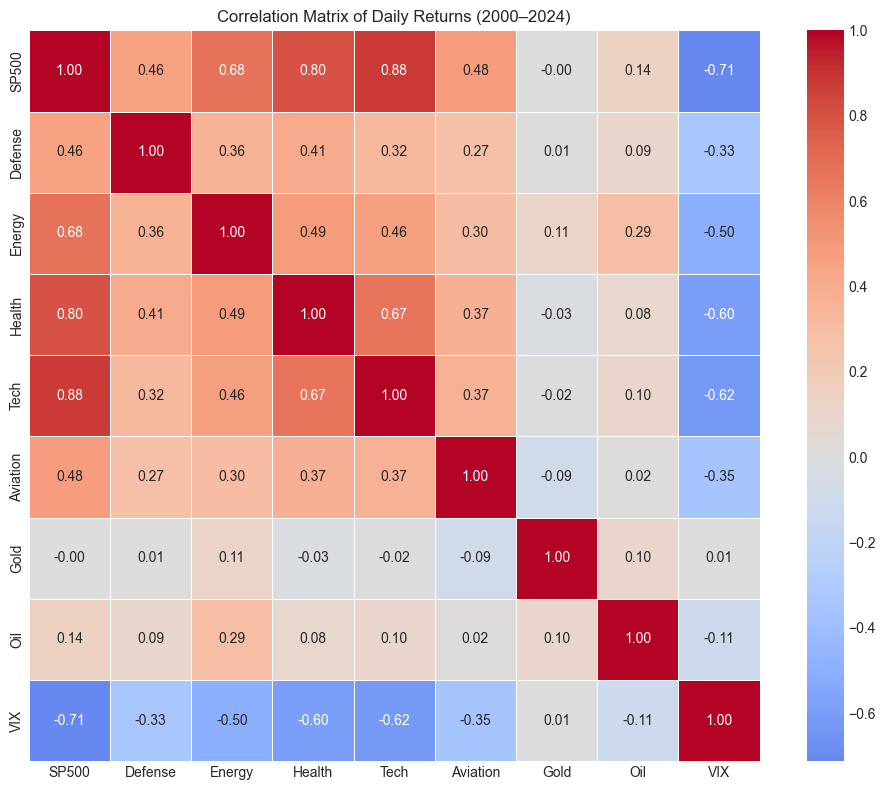

In [66]:
import seaborn as sns

# Select relevant assets for correlation analysis
corr_cols = ["SP500", "Defense", "Energy", "Health", "Tech", "Aviation", "Gold", "Oil", "VIX"]
corr = returns[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Matrix of Daily Returns (2000–2024)")
plt.tight_layout()
plt.show()

## Summary of Findings

### S&P 500 Returns
| Crisis | Pre Return (%) | Post Return (%) | Pre Volatility (%) | Post Volatility (%) |
|---|---|---|---|---|
| 9/11 (2001) | -0.421 | 0.042 | 1.082 | 2.012 |
| Iraq War (2003) | 0.220 | 0.115 | 1.565 | 1.450 |
| Financial Crisis (2008) | -0.181 | -1.275 | 1.500 | 4.842 |
| COVID-19 (2020) | -0.639 | 0.007 | 2.985 | 5.683 |
| Russia-Ukraine (2022) | -0.194 | 0.341 | 1.414 | 1.502 |
| Israel-Hamas (2023) | -0.160 | 0.067 | 0.785 | 0.957 |

### Sector Returns Post-Crisis (avg daily %)
| Crisis | Defense | Energy | Health | Tech | Aviation |
|---|---|---|---|---|---|
| 9/11 (2001) | 1.026 | -0.006 | -0.191 | 0.168 | -0.743 |
| Iraq War (2003) | -0.285 | -0.017 | 0.008 | -0.018 | -0.202 |
| Financial Crisis (2008) | -1.196 | -1.751 | -1.041 | -1.252 | 0.044 |
| COVID-19 (2020) | 0.255 | 0.188 | 0.118 | 0.084 | -2.179 |
| Russia-Ukraine (2022) | 0.770 | 0.760 | 0.359 | 0.358 | -0.158 |
| Israel-Hamas (2023) | 0.587 | 0.009 | -0.061 | 0.136 | -0.517 |

### Asset Correlations (2000–2024)
| Asset | Correlation with SP500 | Interpretation |
|---|---|---|
| Tech | 0.88 | Moves almost in lockstep with the market |
| Health | 0.80 | High correlation — follows broad market |
| Energy | 0.68 | Moderate — partly driven by oil prices |
| Defense | 0.46 | Lower — partially decoupled from market |
| Aviation | 0.48 | Moderate — sensitive to economic cycles |
| Gold | -0.00 | No correlation — effective diversifier |
| Oil | 0.14 | Weak — mostly commodity-driven |
| VIX | -0.71 | Strong inverse — fear rises when market falls |

### MSCI World vs S&P 500 (2010 onwards)
| Crisis | Observation |
|---|---|
| COVID-19 (2020) | Both dropped equally — confirming global nature of the crisis |
| Russia-Ukraine (2022) | MSCI World slightly more impacted — higher European exposure |
| Israel-Hamas (2023) | Minimal impact on both — highly correlated movement |
| 2010–2025 trend | S&P 500 grew ~5x vs MSCI World ~2x — US market significantly outperformed |

### Key Observations
- Pre-crisis returns are mostly negative — markets anticipate bad news before it happens
- Post-crisis returns recover quickly for geopolitical crises (9/11, Russia-Ukraine)
- Financial Crisis (2008) is the exception — cumulative return fell −33% over 30 days
- Volatility increases after every crisis, most dramatically in COVID-19 and 2008
- VIX spikes sharply at crisis dates — reaches ~80 in both 2008 and COVID-19
- Defense benefits during geopolitical crises (9/11: +1.026, Russia-Ukraine: +0.770)
- Energy benefits during war (Russia-Ukraine: +0.760) but suffers in financial crises (−1.751)
- Aviation suffers most during health crises (COVID-19: −2.179% daily average)
- Gold has near-zero correlation with S&P 500 — best diversifier in the dataset
- Fed Rate drops aggressively after every crisis except Russia-Ukraine (raised to fight inflation)
- Unemployment spikes are delayed — peaks months after the crisis date
- CPI shows post-COVID inflation surge — fastest rise in 40 years

**Next step: Hypothesis Testing**